In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    LSTM, Dense, Dropout, Bidirectional,
    RepeatVector, TimeDistributed, Input
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

np.random.seed(42)
tf.random.set_seed(42)
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
csv_path = "jena_climate_2009_2016.csv"

df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

print("Columns:", df.columns.tolist())
print("Shape:", df.shape)
print(df.head())

Columns: ['Date Time', 'p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)']
Shape: (420551, 15)
             Date Time  p (mbar)  T (degC)  Tpot (K)  Tdew (degC)  rh (%)  \
0  01.01.2009 00:10:00    996.52     -8.02    265.40        -8.90    93.3   
1  01.01.2009 00:20:00    996.57     -8.41    265.01        -9.28    93.4   
2  01.01.2009 00:30:00    996.53     -8.51    264.91        -9.31    93.9   
3  01.01.2009 00:40:00    996.51     -8.31    265.12        -9.07    94.2   
4  01.01.2009 00:50:00    996.51     -8.27    265.15        -9.04    94.1   

   VPmax (mbar)  VPact (mbar)  VPdef (mbar)  sh (g/kg)  H2OC (mmol/mol)  \
0          3.33          3.11          0.22       1.94             3.12   
1          3.23          3.02          0.21       1.89             3.03   
2          3.21          3.01          0.20       1.88             3.02

In [ ]:
df['Date Time'] = pd.to_datetime(
    df['Date Time'], format='%d.%m.%Y %H:%M:%S', errors='coerce'
)
df = df.set_index('Date Time')
df = df[df.index.notna()]

print("Shape after date parsing:", df.shape)
print(df.head())

Shape after date parsing: (420551, 14)
                     p (mbar)  T (degC)  Tpot (K)  Tdew (degC)  rh (%)  \
Date Time                                                                
2009-01-01 00:10:00    996.52     -8.02    265.40        -8.90    93.3   
2009-01-01 00:20:00    996.57     -8.41    265.01        -9.28    93.4   
2009-01-01 00:30:00    996.53     -8.51    264.91        -9.31    93.9   
2009-01-01 00:40:00    996.51     -8.31    265.12        -9.07    94.2   
2009-01-01 00:50:00    996.51     -8.27    265.15        -9.04    94.1   

                     VPmax (mbar)  VPact (mbar)  VPdef (mbar)  sh (g/kg)  \
Date Time                                                                  
2009-01-01 00:10:00          3.33          3.11          0.22       1.94   
2009-01-01 00:20:00          3.23          3.02          0.21       1.89   
2009-01-01 00:30:00          3.21          3.01          0.20       1.88   
2009-01-01 00:40:00          3.26          3.07          0.19 

In [ ]:
# Selected features matching your CSV column names
cols = ['T (degC)', 'p (mbar)', 'rh (%)', 'wv (m/s)']
data = df[cols].copy()

print("Data shape:", data.shape)
print(data.describe())
print("\nMissing values:\n", data.isnull().sum())

Data shape: (420551, 4)
            T (degC)       p (mbar)         rh (%)       wv (m/s)
count  420551.000000  420551.000000  420551.000000  420551.000000
mean        9.450147     989.212776      76.008259       1.702224
std         8.423365       8.358481      16.476175      65.446714
min       -23.010000     913.600000      12.950000   -9999.000000
25%         3.360000     984.200000      65.210000       0.990000
50%         9.420000     989.580000      79.300000       1.760000
75%        15.470000     994.720000      89.400000       2.860000
max        37.280000    1015.350000     100.000000      28.490000

Missing values:
 T (degC)    0
p (mbar)    0
rh (%)      0
wv (m/s)    0
dtype: int64


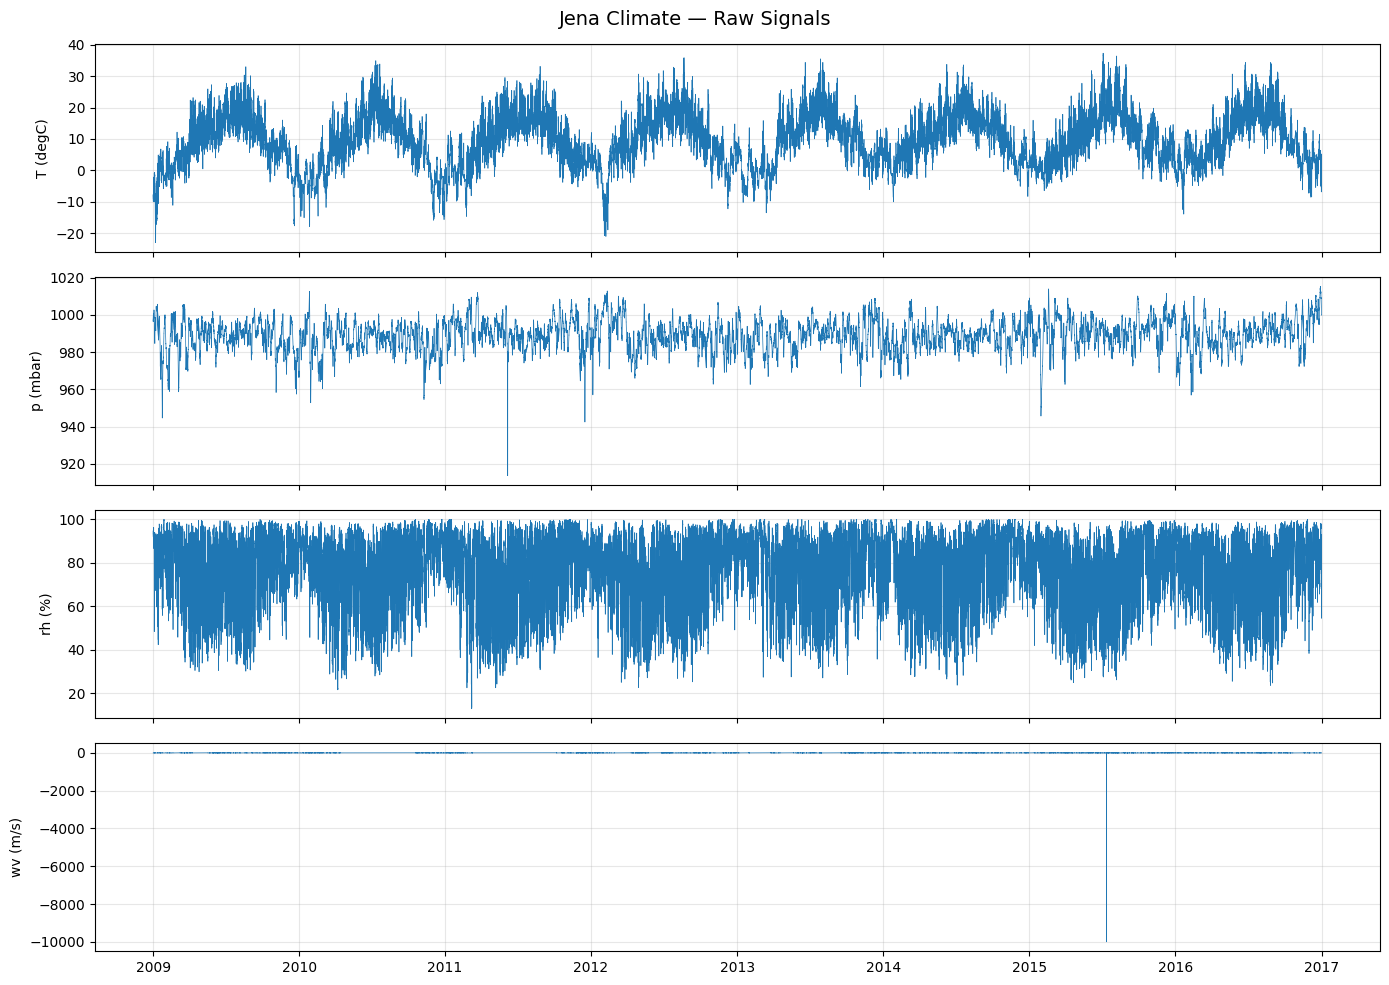

In [ ]:
# Plot raw signals
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
for i, col in enumerate(cols):
    axes[i].plot(data.index, data[col], linewidth=0.5)
    axes[i].set_ylabel(col)
    axes[i].grid(True, alpha=0.3)
plt.suptitle("Jena Climate — Raw Signals", fontsize=14)
plt.tight_layout()
plt.savefig("raw_signals.png", dpi=100)
plt.show()

In [ ]:
# Downsample 10-min → 1-hour
data_hourly = data.resample('1H').mean().dropna()
print("Hourly shape:", data_hourly.shape)

# Scale
scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(data_hourly.values)
print("Scaled shape:", scaled.shape)

Hourly shape: (70041, 4)
Scaled shape: (70041, 4)


In [ ]:
# Train / Val / Test split
n = len(scaled)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train_data = scaled[:train_end]
val_data   = scaled[train_end:val_end]
test_data  = scaled[val_end:]

print(f"Train: {train_data.shape}, Val: {val_data.shape}, Test: {test_data.shape}")

Train: (49028, 4), Val: (10506, 4), Test: (10507, 4)


In [ ]:
# Sliding window helper
def create_sequences(data, time_steps, target_col=0, horizon=1):
    X, y = [], []
    for i in range(len(data) - time_steps - horizon + 1):
        X.append(data[i:i+time_steps])
        y.append(data[i+time_steps:i+time_steps+horizon, target_col])
    return np.array(X), np.array(y)

In [ ]:
# Step 4: Reusable Training & Evaluation Utilities
def train_model(model, X_train, y_train, X_val, y_val,
                epochs=30, batch_size=64, name="model"):
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])

    callbacks = [
        EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6)
    ]

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1
    )

    os.makedirs("models", exist_ok=True)
    model.save(f"models/{name}.keras")
    return history

def plot_history(history, title="Training History"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history['loss'], label='Train Loss')
    axes[0].plot(history.history['val_loss'], label='Val Loss')
    axes[0].set_title(f"{title} — Loss")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MSE")
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(history.history['mae'], label='Train MAE')
    axes[1].plot(history.history['val_mae'], label='Val MAE')
    axes[1].set_title(f"{title} — MAE")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("MAE")
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{title.replace(' ', '_')}.png", dpi=100)
    plt.show()

def evaluate_model(model, X_test, y_test, scaler, target_idx=0, name="model"):
    pred = model.predict(X_test, verbose=0)

    pred_full = np.zeros((len(pred), scaler.n_features_in_))
    pred_full[:, target_idx] = pred.flatten()
    pred_inv = scaler.inverse_transform(pred_full)[:, target_idx]

    true_full = np.zeros((len(y_test), scaler.n_features_in_))
    true_full[:, target_idx] = y_test.flatten()
    true_inv = scaler.inverse_transform(true_full)[:, target_idx]

    mse = mean_squared_error(true_inv, pred_inv)
    mae = mean_absolute_error(true_inv, pred_inv)
    rmse = np.sqrt(mse)

    print(f"\n[{name}] Test MSE : {mse:.4f}")
    print(f"[{name}] Test MAE : {mae:.4f}")
    print(f"[{name}] Test RMSE: {rmse:.4f}")

    return pred_inv, true_inv, (mse, mae, rmse)

In [ ]:
# Step 5: Run All LSTM Models
TIME_STEPS = 24   # past 24 hours
TARGET_COL = 0    # index of 'T (degC)' in our cols list

X_train, y_train = create_sequences(train_data, TIME_STEPS, TARGET_COL)
X_val,   y_val   = create_sequences(val_data,   TIME_STEPS, TARGET_COL)
X_test,  y_test  = create_sequences(test_data,  TIME_STEPS, TARGET_COL)

print("Train X:", X_train.shape, "Train y:", y_train.shape)
print("Features per time step:", X_train.shape[2])

Train X: (49004, 24, 4) Train y: (49004, 1)
Features per time step: 4


Model: "basic_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,729 (69.25 KB)

 Trainable params: 17,729 (69.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0031 - mae: 0.0350 - val_loss: 7.1585e-04 - val_mae: 0.0204 - learning_rate: 0.0010
Epoch 2/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 5.4751e-04 - mae: 0.0178 - val_loss: 4.7163e-04 - val_mae: 0.0162 - learning_rate: 0.0010
Epoch 3/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 4.2381e-04 - mae: 0.0156 - val_loss: 3.8779e-04 - val_mae: 0.0146 - learning_rate: 0.0010
Epoch 4/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 3.2744e-04 - mae: 0.0135 - val_loss: 3.0306e-04 - val_mae: 0.0128 - learning_rate: 0.0010
Epoch 5/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 2.7026e-04 - mae: 0.0122 - val_loss: 2.2733e-04 - val_mae: 0.0109 - learning_rate: 0.0010
Epoch 6/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 2.2780e-04 - mae: 0.0112 - val_loss: 1.9398e-04 - val_mae: 0.0100 - learning_rate: 0.0010
Epoch 7/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 2.0261e-04 - mae: 0.0105 - val_loss: 1.7599

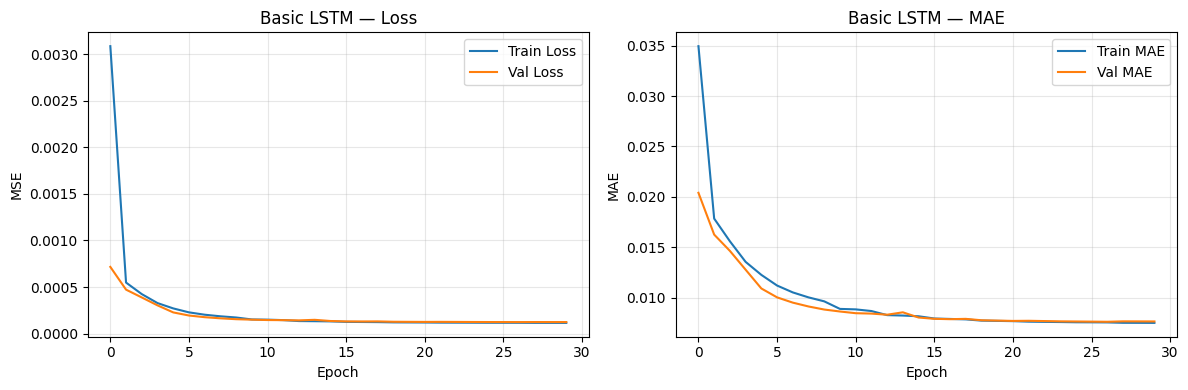


[Basic LSTM] Test MSE : 0.3665
[Basic LSTM] Test MAE : 0.4291
[Basic LSTM] Test RMSE: 0.6054


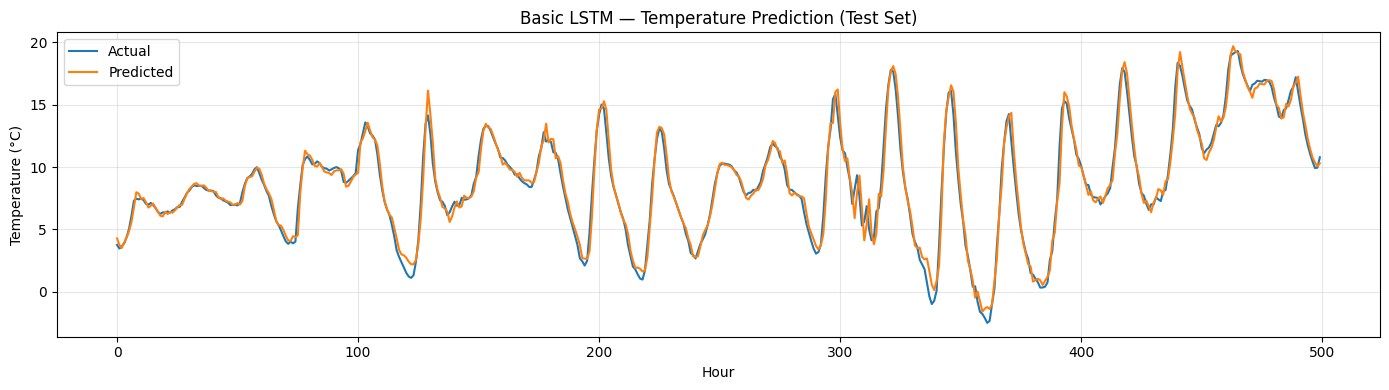

In [ ]:
# 1. Basic LSTM
basic_model = Sequential([
    LSTM(64, input_shape=(TIME_STEPS, X_train.shape[2])),
    Dense(1)
], name="basic_lstm")

basic_model.summary()
history_basic = train_model(basic_model, X_train, y_train, X_val, y_val,
                            epochs=30, batch_size=128, name="basic_lstm")
plot_history(history_basic, "Basic LSTM")
pred_basic, true_basic, metrics_basic = evaluate_model(
    basic_model, X_test, y_test, scaler, TARGET_COL, "Basic LSTM")

plt.figure(figsize=(14, 4))
plt.plot(true_basic[:500], label="Actual")
plt.plot(pred_basic[:500], label="Predicted")
plt.title("Basic LSTM — Temperature Prediction (Test Set)")
plt.xlabel("Hour"); plt.ylabel("Temperature (°C)")
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

Model: "stacked_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 24, 64)         │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,113 (117.63 KB)

 Trainable params: 30,113 (117.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.0038 - mae: 0.0402 - val_loss: 9.7482e-04 - val_mae: 0.0239 - learning_rate: 0.0010
Epoch 2/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 7.2702e-04 - mae: 0.0206 - val_loss: 5.5364e-04 - val_mae: 0.0177 - learning_rate: 0.0010
Epoch 3/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 4.0805e-04 - mae: 0.0153 - val_loss: 2.7318e-04 - val_mae: 0.0120 - learning_rate: 0.0010
Epoch 4/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 2.7002e-04 - mae: 0.0123 - val_loss: 2.0718e-04 - val_mae: 0.0102 - learning_rate: 0.0010
Epoch 5/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 2.1762e-04 - mae: 0.0110 - val_loss: 1.7955e-04 - val_mae: 0.0094 - learning_rate: 0.0010
Epoch 6/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 1.8787e-04 - mae: 0.0101 - val_loss: 1.6172e-04 - val_mae: 0.0088 - learning_rate: 0.0010
Epoch 7/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 1.6919e-04 - mae: 0.0096 - val_loss: 1.

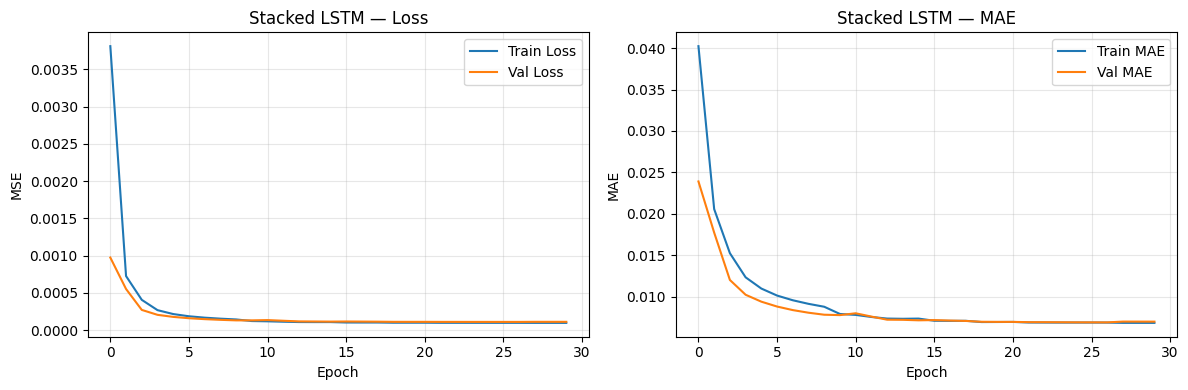


[Stacked LSTM] Test MSE : 0.3149
[Stacked LSTM] Test MAE : 0.3911
[Stacked LSTM] Test RMSE: 0.5611


In [ ]:
# 2. Stacked LSTM
stacked_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(TIME_STEPS, X_train.shape[2])),
    LSTM(32),
    Dense(1)
], name="stacked_lstm")

stacked_model.summary()
history_stacked = train_model(stacked_model, X_train, y_train, X_val, y_val,
                              epochs=30, batch_size=128, name="stacked_lstm")
plot_history(history_stacked, "Stacked LSTM")
pred_stacked, true_stacked, metrics_stacked = evaluate_model(
    stacked_model, X_test, y_test, scaler, TARGET_COL, "Stacked LSTM")

Model: "bidirectional_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 128)            │        35,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,457 (138.50 KB)

 Trainable params: 35,457 (138.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.0064 - mae: 0.0436 - val_loss: 9.1857e-04 - val_mae: 0.0230 - learning_rate: 0.0010
Epoch 2/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 7.4660e-04 - mae: 0.0210 - val_loss: 6.7376e-04 - val_mae: 0.0200 - learning_rate: 0.0010
Epoch 3/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 4.9108e-04 - mae: 0.0169 - val_loss: 4.2936e-04 - val_mae: 0.0155 - learning_rate: 0.0010
Epoch 4/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 3.6354e-04 - mae: 0.0144 - val_loss: 3.2776e-04 - val_mae: 0.0133 - learning_rate: 0.0010
Epoch 5/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 3.0266e-04 - mae: 0.0131 - val_loss: 2.6771e-04 - val_mae: 0.0118 - learning_rate: 0.0010
Epoch 6/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 2.6104e-04 - mae: 0.0121 - val_loss: 2.3270e-04 - val_mae: 0.0109 - learning_rate: 0.0010
Epoch 7/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 2.3174e-04 - mae: 0.0113 - val_loss: 2.091

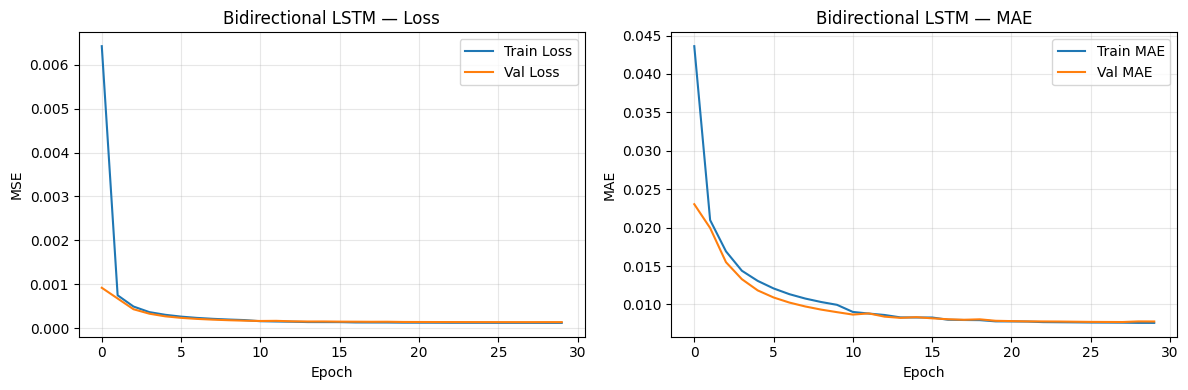


[Bidirectional LSTM] Test MSE : 0.3758
[Bidirectional LSTM] Test MAE : 0.4333
[Bidirectional LSTM] Test RMSE: 0.6130


In [ ]:
# 3. Bidirectional LSTM
bidir_model = Sequential([
    Bidirectional(LSTM(64), input_shape=(TIME_STEPS, X_train.shape[2])),
    Dense(1)
], name="bidirectional_lstm")

bidir_model.summary()
history_bidir = train_model(bidir_model, X_train, y_train, X_val, y_val,
                            epochs=30, batch_size=128, name="bidirectional_lstm")
plot_history(history_bidir, "Bidirectional LSTM")
pred_bidir, true_bidir, metrics_bidir = evaluate_model(
    bidir_model, X_test, y_test, scaler, TARGET_COL, "Bidirectional LSTM")

Model: "multivariate_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 64)             │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,777 (77.25 KB)

 Trainable params: 19,777 (77.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0085 - mae: 0.0614 - val_loss: 0.0025 - val_mae: 0.0422 - learning_rate: 0.0010
Epoch 2/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0015 - mae: 0.0302 - val_loss: 0.0038 - val_mae: 0.0567 - learning_rate: 0.0010
Epoch 3/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0011 - mae: 0.0252 - val_loss: 0.0022 - val_mae: 0.0422 - learning_rate: 0.0010
Epoch 4/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 7.8036e-04 - mae: 0.0214 - val_loss: 0.0022 - val_mae: 0.0424 - learning_rate: 0.0010
Epoch 5/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 6.0927e-04 - mae: 0.0188 - val_loss: 0.0013 - val_mae: 0.0317 - learning_rate: 0.0010
Epoch 6/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 5.0703e-04 - mae: 0.0170 - val_loss: 0.0016 - val_mae: 0.0365 - learning_rate: 0.0010
Epoch 7/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 4.3488e-04 - mae: 0.0157 - val_loss: 0.0012 - val_mae: 0.0306 - learning_rat

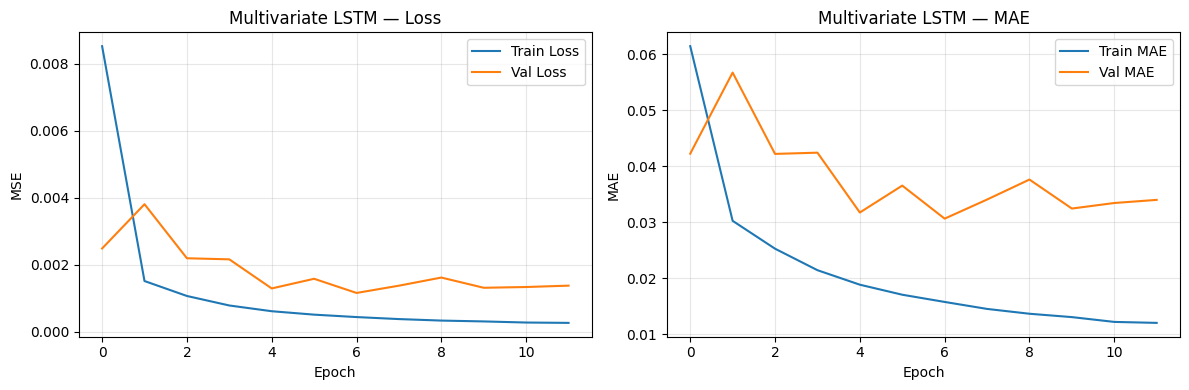


[Multivariate LSTM] Test MSE : 3.7414
[Multivariate LSTM] Test MAE : 1.7464
[Multivariate LSTM] Test RMSE: 1.9343


In [ ]:
# 4. Multivariate LSTM
multi_model = Sequential([
    LSTM(64, input_shape=(TIME_STEPS, X_train.shape[2])),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
], name="multivariate_lstm")

multi_model.summary()
history_multi = train_model(multi_model, X_train, y_train, X_val, y_val,
                            epochs=30, batch_size=128, name="multivariate_lstm")
plot_history(history_multi, "Multivariate LSTM")
pred_multi, true_multi, metrics_multi = evaluate_model(
    multi_model, X_test, y_test, scaler, TARGET_COL, "Multivariate LSTM")

Model: "many_to_one_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                   │ (None, 24, 128)        │        68,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 119,617 (467.25 KB)

 Trainable params: 119,617 (467.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0046 - mae: 0.0408 - val_loss: 8.2316e-04 - val_mae: 0.0219 - learning_rate: 0.0010
Epoch 2/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 6.9151e-04 - mae: 0.0202 - val_loss: 5.0338e-04 - val_mae: 0.0169 - learning_rate: 0.0010
Epoch 3/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 3.9778e-04 - mae: 0.0152 - val_loss: 2.8167e-04 - val_mae: 0.0125 - learning_rate: 0.0010
Epoch 4/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 2.6277e-04 - mae: 0.0122 - val_loss: 2.7214e-04 - val_mae: 0.0128 - learning_rate: 0.0010
Epoch 5/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 2.1745e-04 - mae: 0.0111 - val_loss: 2.8856e-04 - val_mae: 0.0136 - learning_rate: 0.0010
Epoch 6/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 1.9056e-04 - mae: 0.0103 - val_loss: 1.5588e-04 - val_mae: 0.0088 - learning_rate: 0.0010
Epoch 7/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 1.6652e-04 - mae: 0.0096 - val_loss: 1.374

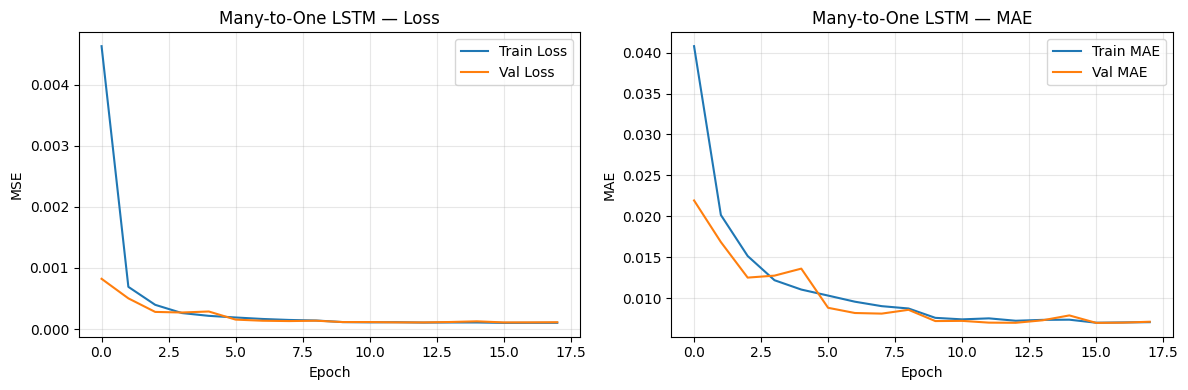


[Many-to-One LSTM] Test MSE : 0.3215
[Many-to-One LSTM] Test MAE : 0.3959
[Many-to-One LSTM] Test RMSE: 0.5670


In [ ]:
# 5. Many-to-One LSTM
m2o_model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(TIME_STEPS, X_train.shape[2])),
    LSTM(64),
    Dense(32, activation="relu"),
    Dense(1)
], name="many_to_one_lstm")

m2o_model.summary()
history_m2o = train_model(m2o_model, X_train, y_train, X_val, y_val,
                          epochs=30, batch_size=128, name="many_to_one_lstm")
plot_history(history_m2o, "Many-to-One LSTM")
pred_m2o, true_m2o, metrics_m2o = evaluate_model(
    m2o_model, X_test, y_test, scaler, TARGET_COL, "Many-to-One LSTM")

M2M Train X: (48999, 24, 4) Train y: (48999, 6)


Model: "many_to_many_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_7 (LSTM)                   │ (None, 24, 64)         │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 6, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 6, 64)          │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 6, 1)           │            65 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 83,777 (327.25 KB)

 Trainable params: 83,777 (327.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.0093 - mae: 0.0618 - val_loss: 0.0027 - val_mae: 0.0398
Epoch 2/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0019 - mae: 0.0340 - val_loss: 0.0016 - val_mae: 0.0301
Epoch 3/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0015 - mae: 0.0297 - val_loss: 0.0013 - val_mae: 0.0270
Epoch 4/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0013 - mae: 0.0270 - val_loss: 0.0011 - val_mae: 0.0244
Epoch 5/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0011 - mae: 0.0248 - val_loss: 0.0010 - val_mae: 0.0229
Epoch 6/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0010 - mae: 0.0234 - val_loss: 9.3744e-04 - val_mae: 0.0221
Epoch 7/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 9.4615e-04 - mae: 0.0225 - val_loss: 8.8999e-04 - val_mae: 0.0213
Epoch 8/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 8.9764e-04 - mae: 0.0218 - val_loss: 8.5622e-04 - val_mae: 0.0208
Epoch 9/30
383/383 ━━━━━━━━━

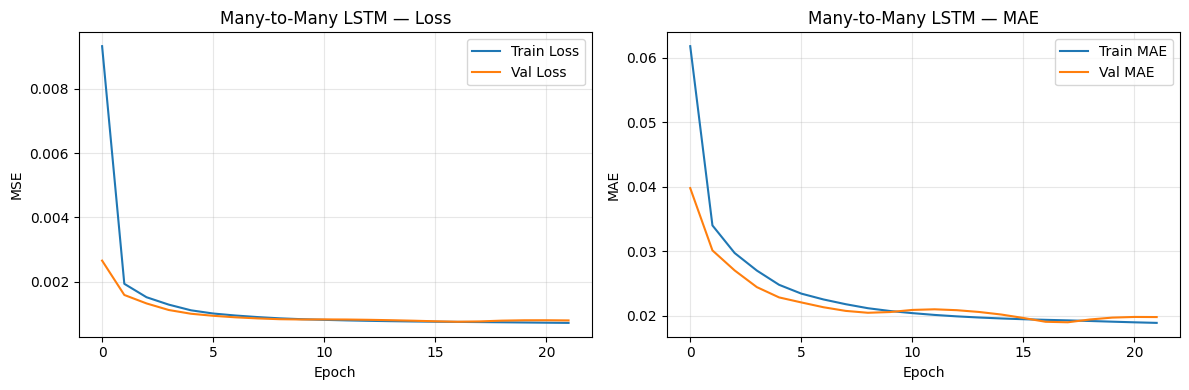

Prediction shape: (10478, 6, 1)


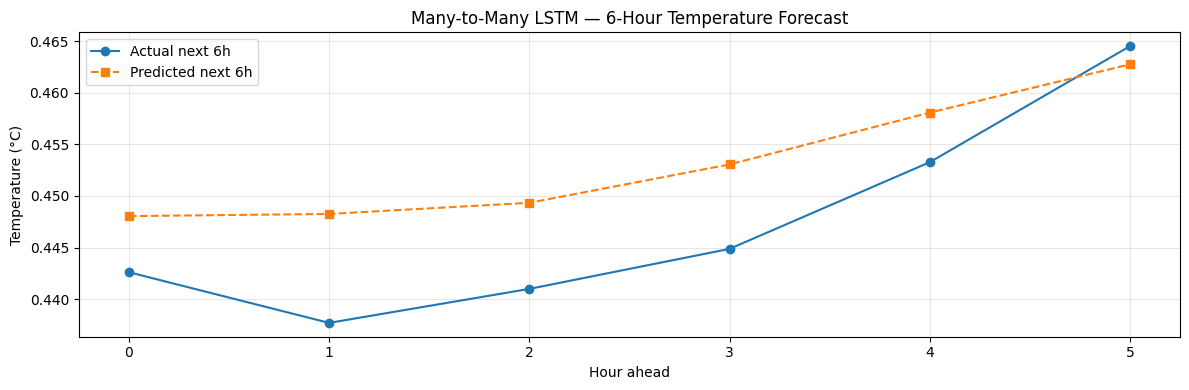

In [ ]:
# 6. Many-to-Many LSTM (Next 6 hours)
HORIZON = 6

X_train_m2m, y_train_m2m = create_sequences(train_data, TIME_STEPS, TARGET_COL, HORIZON)
X_val_m2m,   y_val_m2m   = create_sequences(val_data,   TIME_STEPS, TARGET_COL, HORIZON)
X_test_m2m,  y_test_m2m  = create_sequences(test_data,  TIME_STEPS, TARGET_COL, HORIZON)

print("M2M Train X:", X_train_m2m.shape, "Train y:", y_train_m2m.shape)

m2m_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(TIME_STEPS, X_train.shape[2])),
    LSTM(64),
    RepeatVector(HORIZON),
    LSTM(64, return_sequences=True),
    TimeDistributed(Dense(1))
], name="many_to_many_lstm")

m2m_model.summary()
m2m_model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history_m2m = m2m_model.fit(
    X_train_m2m, y_train_m2m,
    validation_data=(X_val_m2m, y_val_m2m),
    epochs=30, batch_size=128,
    callbacks=[EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)],
    verbose=1
)
plot_history(history_m2m, "Many-to-Many LSTM")

pred_m2m = m2m_model.predict(X_test_m2m, verbose=0)
print("Prediction shape:", pred_m2m.shape)

sample_idx = 0
plt.figure(figsize=(12, 4))
plt.plot(y_test_m2m[sample_idx], 'o-', label="Actual next 6h")
plt.plot(pred_m2m[sample_idx].flatten(), 's--', label="Predicted next 6h")
plt.title("Many-to-Many LSTM — 6-Hour Temperature Forecast")
plt.xlabel("Hour ahead"); plt.ylabel("Temperature (°C)")
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

AE Train shape: (49005, 24, 4)
AE Val   shape: (10483, 24, 4)
AE Test  shape: (10484, 24, 4)


Model: "lstm_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 24, 4)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_12 (LSTM)                  │ (None, 32)             │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_2 (RepeatVector)  │ (None, 24, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 24, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 24, 4)          │           132 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,188 (51.52 KB)

 Trainable params: 13,188 (51.52 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 17s 26ms/step - loss: 0.0299 - mae: 0.0955 - val_loss: 0.0054 - val_mae: 0.0472
Epoch 2/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0043 - mae: 0.0409 - val_loss: 0.0037 - val_mae: 0.0373
Epoch 3/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0031 - mae: 0.0351 - val_loss: 0.0026 - val_mae: 0.0323
Epoch 4/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0021 - mae: 0.0290 - val_loss: 0.0018 - val_mae: 0.0266
Epoch 5/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0016 - mae: 0.0257 - val_loss: 0.0016 - val_mae: 0.0248
Epoch 6/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0015 - mae: 0.0244 - val_loss: 0.0014 - val_mae: 0.0236
Epoch 7/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0013 - mae: 0.0234 - val_loss: 0.0014 - val_mae: 0.0245
Epoch 8/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0013 - mae: 0.0228 - val_loss: 0.0013 - val_mae: 0.0224
Epoch 9/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - 

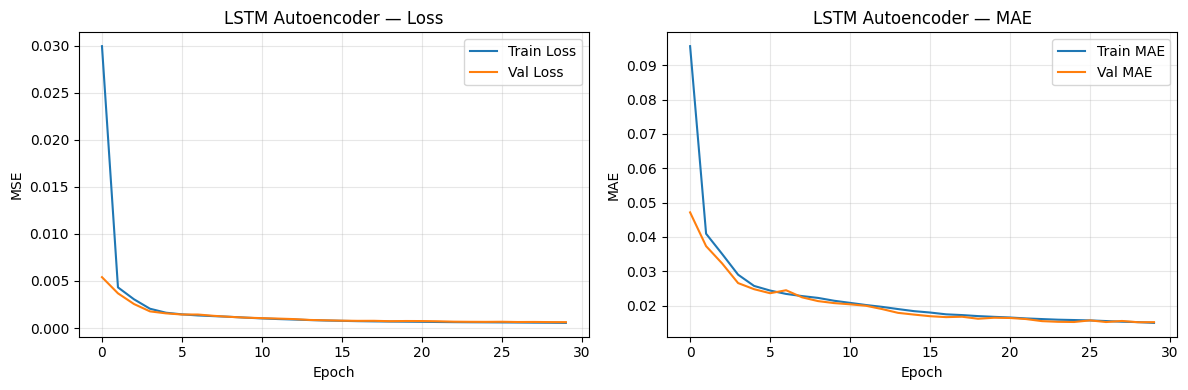


Anomaly threshold : 0.001729
Detected anomalies: 104 out of 10484 windows (0.99%)


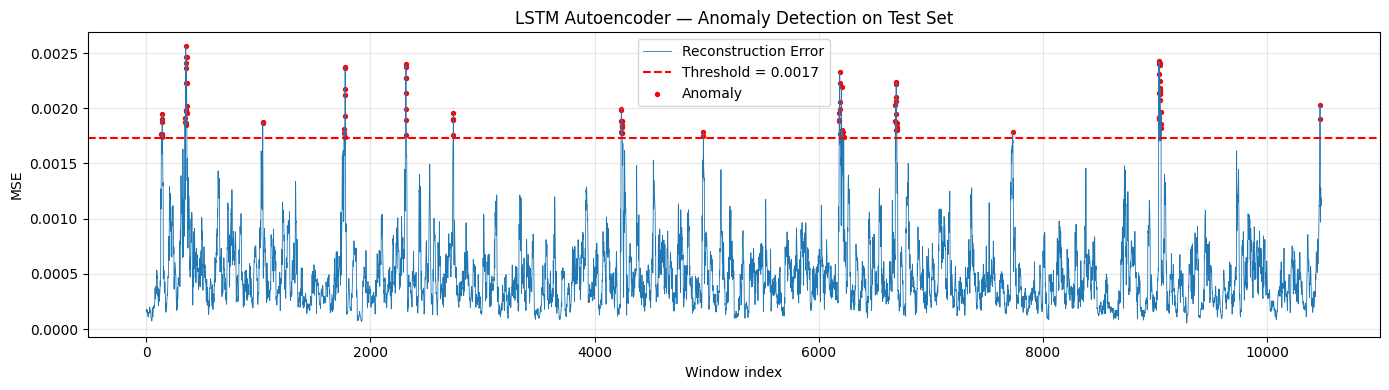

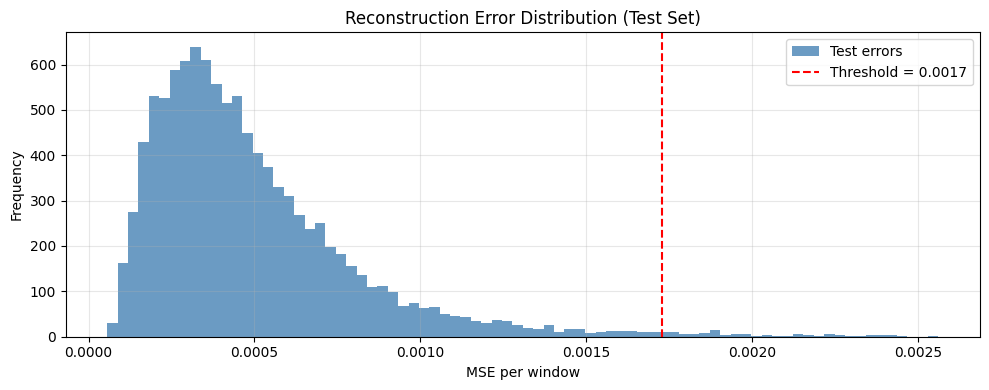

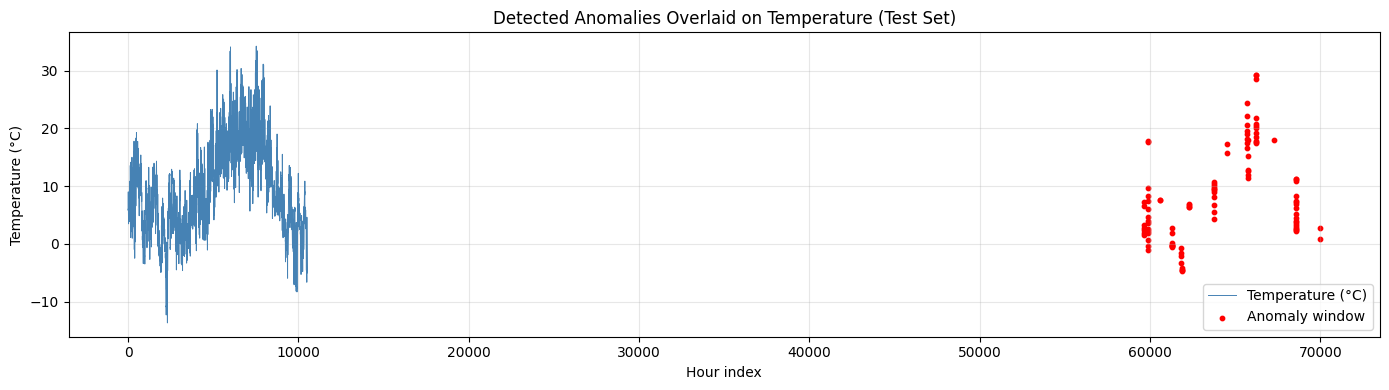


Top 10 most anomalous windows (by MSE):
Rank  Window idx    MSE         Time (Test)
1     352           0.002562    2010-02-20 21:30:00
2     359           0.002464    2010-02-20 22:40:00
3     358           0.002464    2010-02-20 22:30:00
4     9033          0.002425    2010-04-22 04:20:00
5     9041          0.002413    2010-04-22 05:40:00
6     351           0.002409    2010-02-20 21:20:00
7     9032          0.002398    2010-04-22 04:10:00
8     2317          0.002398    2010-03-06 13:00:00
9     9040          0.002396    2010-04-22 05:30:00
10    1774          0.002376    2010-03-02 18:30:00


In [ ]:
# =============================================================
# 7. LSTM Autoencoder (Anomaly Detection)
# =============================================================
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense
from tensorflow.keras.callbacks import EarlyStopping

# ---------- 1. Build sequences ----------
AE_TIME_STEPS = 24

def create_ae_sequences(data, time_steps):
    X = []
    for i in range(len(data) - time_steps + 1):
        X.append(data[i:i + time_steps])
    return np.array(X)

X_train_ae = create_ae_sequences(train_data, AE_TIME_STEPS)
X_val_ae   = create_ae_sequences(val_data,   AE_TIME_STEPS)
X_test_ae  = create_ae_sequences(test_data,  AE_TIME_STEPS)
n_features = X_train_ae.shape[2]

print("AE Train shape:", X_train_ae.shape)
print("AE Val   shape:", X_val_ae.shape)
print("AE Test  shape:", X_test_ae.shape)

# ---------- 2. Build model ----------
inputs  = Input(shape=(AE_TIME_STEPS, n_features))
encoded = LSTM(32, activation="relu")(inputs)
decoded = RepeatVector(AE_TIME_STEPS)(encoded)
decoded = LSTM(32, activation="relu", return_sequences=True)(decoded)
outputs = TimeDistributed(Dense(n_features))(decoded)

autoencoder = Model(inputs, outputs, name="lstm_autoencoder")
autoencoder.compile(optimizer="adam", loss="mse", metrics=["mae"])   # <-- added mae
autoencoder.summary()

# ---------- 3. Train ----------
history_ae = autoencoder.fit(
    X_train_ae, X_train_ae,
    validation_data=(X_val_ae, X_val_ae),
    epochs=30,
    batch_size=128,
    callbacks=[EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)],
    verbose=1
)

# ---------- 4. Plot training history (robust — works with or without MAE) ----------
def plot_history_ae(history, title="Training History"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Loss (always available)
    axes[0].plot(history.history['loss'], label='Train Loss')
    axes[0].plot(history.history['val_loss'], label='Val Loss')
    axes[0].set_title(f"{title} — Loss")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MSE")
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    # MAE (only if present)
    if 'mae' in history.history:
        axes[1].plot(history.history['mae'], label='Train MAE')
        axes[1].plot(history.history['val_mae'], label='Val MAE')
        axes[1].set_title(f"{title} — MAE")
        axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("MAE")
        axes[1].legend(); axes[1].grid(True, alpha=0.3)
    else:
        axes[1].text(0.5, 0.5, "No MAE metric tracked",
                     ha='center', va='center', fontsize=12)
        axes[1].set_title(f"{title} — MAE (not available)")
        axes[1].axis('off')

    plt.tight_layout()
    plt.savefig(f"{title.replace(' ', '_')}.png", dpi=100)
    plt.show()

plot_history_ae(history_ae, "LSTM Autoencoder")

# ---------- 5. Reconstruction error ----------
reconstructions = autoencoder.predict(X_test_ae, verbose=0)
mse_per_sample  = np.mean(np.power(X_test_ae - reconstructions, 2), axis=(1, 2))

train_recon = autoencoder.predict(X_train_ae, verbose=0)
train_mse   = np.mean(np.power(X_train_ae - train_recon, 2), axis=(1, 2))

threshold = np.mean(train_mse) + 3 * np.std(train_mse)
anomalies = mse_per_sample > threshold

print(f"\nAnomaly threshold : {threshold:.6f}")
print(f"Detected anomalies: {anomalies.sum()} out of {len(anomalies)} windows "
      f"({100 * anomalies.mean():.2f}%)")

# ---------- 6. Main anomaly plot ----------
plt.figure(figsize=(14, 4))
plt.plot(mse_per_sample, label="Reconstruction Error", linewidth=0.6)
plt.axhline(threshold, color='r', linestyle='--',
            label=f"Threshold = {threshold:.4f}")
plt.scatter(np.where(anomalies)[0], mse_per_sample[anomalies],
            color='red', s=8, label="Anomaly")
plt.title("LSTM Autoencoder — Anomaly Detection on Test Set")
plt.xlabel("Window index"); plt.ylabel("MSE")
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("LSTM_Autoencoder_Anomalies.png", dpi=100)
plt.show()

# ---------- 7. Bonus: histogram of reconstruction errors ----------
plt.figure(figsize=(10, 4))
plt.hist(mse_per_sample, bins=80, color='steelblue', alpha=0.8, label='Test errors')
plt.axvline(threshold, color='r', linestyle='--', label=f"Threshold = {threshold:.4f}")
plt.title("Reconstruction Error Distribution (Test Set)")
plt.xlabel("MSE per window"); plt.ylabel("Frequency")
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("LSTM_Autoencoder_ErrorHist.png", dpi=100)
plt.show()

# ---------- 8. Bonus: anomaly overlay on temperature ----------
# Map each window's anomaly flag to its starting time index
test_start_idx = len(train_data) + len(val_data)
# The windows overlap; take the first timestep of each window as anchor
anomaly_idx = np.where(anomalies)[0] + test_start_idx

# Reconstruct actual temperature signal on the test set (inverse-scaled)
temp_scaled = test_data[:, TARGET_COL]
temp_full = np.zeros((len(temp_scaled), scaler.n_features_in_))
temp_full[:, TARGET_COL] = temp_scaled
temp_actual = scaler.inverse_transform(temp_full)[:, TARGET_COL]

plt.figure(figsize=(14, 4))
plt.plot(temp_actual, color='steelblue', linewidth=0.7, label='Temperature (°C)')
plt.scatter(anomaly_idx,
            temp_actual[anomaly_idx - test_start_idx],
            color='red', s=10, label='Anomaly window')
plt.title("Detected Anomalies Overlaid on Temperature (Test Set)")
plt.xlabel("Hour index"); plt.ylabel("Temperature (°C)")
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("LSTM_Autoencoder_Overlay.png", dpi=100)
plt.show()

# ---------- 9. Top-10 most anomalous windows ----------
top_k = 10
top_idx = np.argsort(mse_per_sample)[-top_k:][::-1]
print(f"\nTop {top_k} most anomalous windows (by MSE):")
print(f"{'Rank':<6}{'Window idx':<14}{'MSE':<12}{'Time (Test)'}")
for rank, i in enumerate(top_idx, 1):
    t = df.index[test_start_idx + i] if (test_start_idx + i) < len(df) else "N/A"
    print(f"{rank:<6}{i:<14}{mse_per_sample[i]:<12.6f}{t}")

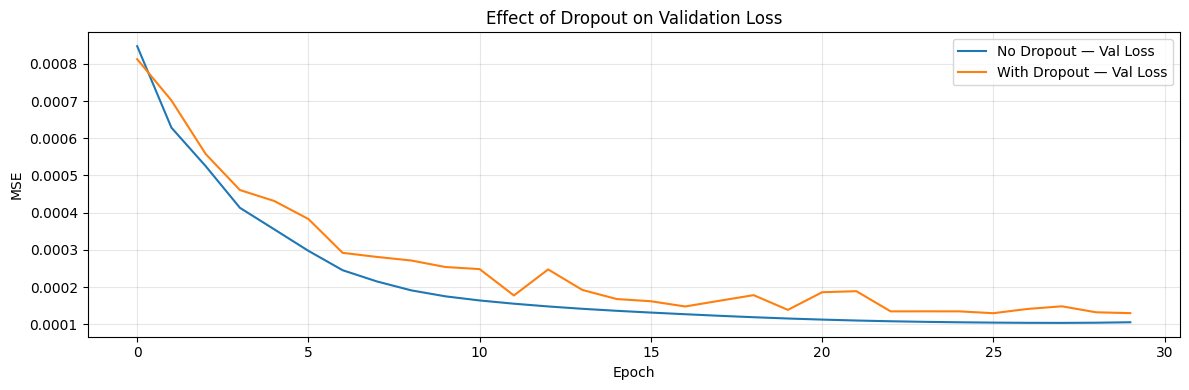


[No Dropout] Test MSE : 0.3244
[No Dropout] Test MAE : 0.4002
[No Dropout] Test RMSE: 0.5696

[With Dropout] Test MSE : 0.3267
[With Dropout] Test MAE : 0.3992
[With Dropout] Test RMSE: 0.5716


In [ ]:
# 8. LSTM with Dropout — Comparison
no_dropout = Sequential([
    LSTM(64, input_shape=(TIME_STEPS, X_train.shape[2])),
    Dense(1)
], name="no_dropout")
no_dropout.compile(optimizer="adam", loss="mse", metrics=["mae"])
hist_no_drop = no_dropout.fit(X_train, y_train, validation_data=(X_val, y_val),
                              epochs=30, batch_size=128, verbose=0)

with_dropout = Sequential([
    LSTM(64, input_shape=(TIME_STEPS, X_train.shape[2])),
    Dropout(0.3),
    Dense(1)
], name="with_dropout")
with_dropout.compile(optimizer="adam", loss="mse", metrics=["mae"])
hist_drop = with_dropout.fit(X_train, y_train, validation_data=(X_val, y_val),
                             epochs=30, batch_size=128, verbose=0)

plt.figure(figsize=(12, 4))
plt.plot(hist_no_drop.history['val_loss'], label="No Dropout — Val Loss")
plt.plot(hist_drop.history['val_loss'],    label="With Dropout — Val Loss")
plt.title("Effect of Dropout on Validation Loss")
plt.xlabel("Epoch"); plt.ylabel("MSE")
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

pred_no_drop, _, m_no_drop = evaluate_model(no_dropout, X_test, y_test, scaler, TARGET_COL, "No Dropout")
pred_drop,    _, m_drop    = evaluate_model(with_dropout, X_test, y_test, scaler, TARGET_COL, "With Dropout")



=== Final Model Comparison ===
                       MSE     MAE    RMSE
Stacked LSTM        0.3149  0.3911  0.5611
Many-to-One LSTM    0.3215  0.3959  0.5670
No Dropout          0.3244  0.4002  0.5696
With Dropout        0.3267  0.3992  0.5716
Basic LSTM          0.3665  0.4291  0.6054
Bidirectional LSTM  0.3758  0.4333  0.6130
Multivariate LSTM   3.7414  1.7464  1.9343


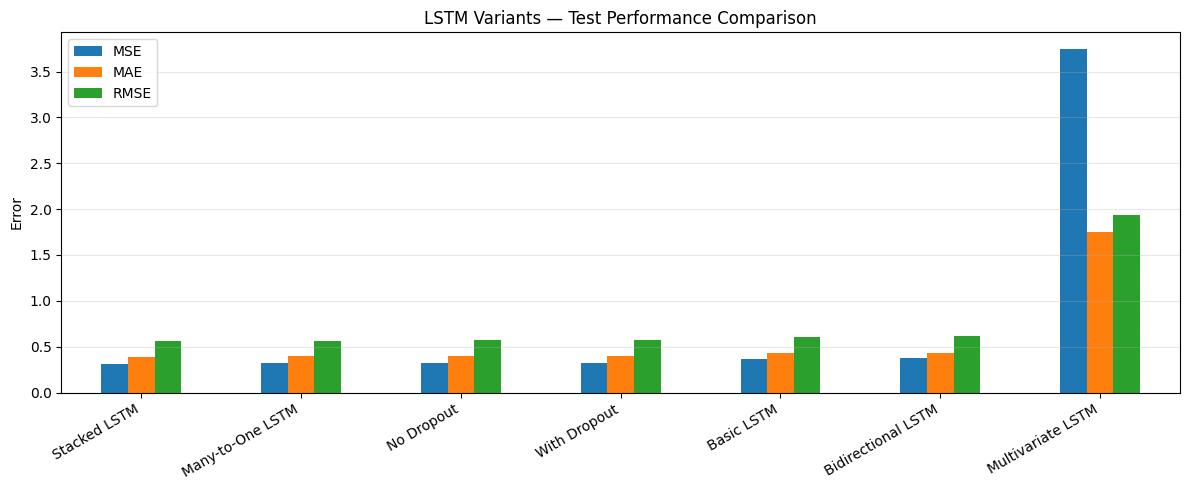

In [ ]:
# Step 6: Final Comparison Table
results = {
    "Basic LSTM":         metrics_basic,
    "Stacked LSTM":       metrics_stacked,
    "Bidirectional LSTM": metrics_bidir,
    "Multivariate LSTM":  metrics_multi,
    "Many-to-One LSTM":   metrics_m2o,
    "No Dropout":         m_no_drop,
    "With Dropout":       m_drop,
}

results_df = pd.DataFrame(results, index=["MSE", "MAE", "RMSE"]).T
results_df = results_df.sort_values("RMSE")
print("\n=== Final Model Comparison ===")
print(results_df.round(4))

results_df.plot(kind="bar", figsize=(12, 5))
plt.title("LSTM Variants — Test Performance Comparison")
plt.ylabel("Error")
plt.xticks(rotation=30, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=100)
plt.show()

In [ ]:
# Step 7: Text / Next-Word LSTM Demo
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Embedding

corpus = """
the weather is cold today and it will rain tomorrow
the sun is bright and the sky is clear
temperature is rising in the summer season
winter brings snow and freezing temperatures
climate change affects weather patterns globally
""" * 50

tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])
vocab_size = len(tokenizer.word_index) + 1
print("Vocabulary size:", vocab_size)

sequences = []
for line in corpus.split("\n"):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        sequences.append(token_list[:i+1])

max_len = max(len(s) for s in sequences)
sequences = pad_sequences(sequences, maxlen=max_len, padding='pre')

X_text = sequences[:, :-1]
y_text = to_categorical(sequences[:, -1], num_classes=vocab_size)

text_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=32, input_length=max_len-1),
    LSTM(64),
    Dense(vocab_size, activation="softmax")
], name="text_lstm")

text_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
text_model.summary()
text_model.fit(X_text, y_text, epochs=200, verbose=0)

def predict_next_word(seed_text, n_words=5):
    for _ in range(n_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        pred = np.argmax(text_model.predict(token_list, verbose=0), axis=-1)[0]
        for word, idx in tokenizer.word_index.items():
            if idx == pred:
                seed_text += " " + word
                break
    return seed_text

print(predict_next_word("the weather is"))
print(predict_next_word("temperature is"))

Vocabulary size: 30


Model: "text_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_16 (LSTM)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

the weather is cold today and it will
temperature is rising in the summer season
